In [2]:
import re

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

print(pd.__version__)

2.3.3


In [3]:
# Helper functions
def style_diff(df, df_orig):
        style = {True: '', 
                 False: 'color: red; background-color: yellow'}
        df_style = (df == df_orig).replace(style)
        return df.style.apply(lambda x: df_style, axis=None)

def random_subset_diff(df, df_orig, n=200):
    if df.shape[0] < n:
        n = df.shape[0]
    return style_diff(df.sample(n), df_orig.sample(n))
    
def print_df(df, desc, rows=5):
    print(f'DataFrame of {desc} with shape {df.shape}:', 
          df.head(rows), sep='\n', end='\n'*2)

In [4]:
# True if looking only at vegan foods
vegan = True

# Parameters for calculating DV amounts

# weight in kg
weight = 70.0
# kcal per day
kcal = 2800.0


In [5]:
# Create DataFrames
category_r = pd.read_csv('./data/food_category.csv',
                       dtype={'id': float, 'code': str, 'description': str})

food_r = pd.read_csv('./data/food.csv',
                       dtype={'fdc_id': int,'data_type': str, 
                              'description': str,
                              'food_category_id': float, 
                              'publication_date': object})

nutrient_r = pd.read_csv('./data/nutrient.csv',
                       dtype={'id': int,'name': str, 
                              'unit_name': str,
                              'nutrient_nbr': float, 
                              'rank': float})

portion_r = pd.read_csv('./data/food_portion.csv',
                       dtype={'id': int,'fdc_id': int,'seq_num': float,
                              'amount': float, 'measure_unit_id': int,
                              'portion_description': str,'modifier': str,
                              'gram_weight': float, 'data_points': float,
                              'footnote': str, 'min_year_acquired': float})

measure_r = pd.read_csv('./data/measure_unit.csv',
                       dtype={'id': int, 'name': str})

food_nutrient_r = pd.read_csv('./data/food_nutrient.csv',
                              dtype={'id': int, 'fdc_id': int,
                                     'nutrient_id': int, 'amount': float})

dfs = {'category': category_r, 'food': food_r, 'food_nutrient': food_nutrient_r,
       'nutrient': nutrient_r, 'portion': portion_r, 'measure': measure_r}


In [6]:
for name, df in dfs.items():
    nans = df[df.isna().any(axis=1)]
    if not nans.empty:
        print(f'{nans.shape[0]}/{df.shape[0]} Rows with missing values in: {name}')
        print(f'Columns with missing values:', 
              df.columns[df.isna().any()].to_list())
        print(df[df.isna().any(axis=1)].head(5))
    else:
        print(f'{name} has no missing values.')

category has no missing values.
food has no missing values.
644125/644125 Rows with missing values in: food_nutrient
Columns with missing values: ['derivation_id', 'min', 'max', 'median', 'footnote', 'min_year_acquired']
        id  fdc_id  nutrient_id   amount  data_points  derivation_id  min  \
0  1283674  167512         1003     5.88            1           46.0  NaN   
1  1283675  167512         1007     3.50            1           46.0  NaN   
2  1283676  167512         1062  1286.00            0           49.0  NaN   
3  1283677  167512         1079     1.20            1           46.0  NaN   
4  1283678  167512         1089     2.12            1           46.0  NaN   

   max  median footnote  min_year_acquired  
0  NaN     NaN      NaN                NaN  
1  NaN     NaN      NaN                NaN  
2  NaN     NaN      NaN                NaN  
3  NaN     NaN      NaN                NaN  
4  NaN     NaN      NaN                NaN  
23/474 Rows with missing values in: nutrient
C

DataFrame of nutrient with shape (474, 3):
     id                              nutrient unit_name
0  2047      Energy (Atwater General Factors)      KCAL
1  2048     Energy (Atwater Specific Factors)      KCAL
2  1001                                Solids         G
3  1002                              Nitrogen         G
4  1003                               Protein         G
5  1004                     Total lipid (fat)         G
6  1005           Carbohydrate, by difference         G
7  1006  Fiber, crude (DO NOT USE - Archived)         G
8  1007                                   Ash         G
9  1008                                Energy      KCAL

DataFrame of category with shape (28, 2):
    id                category
0  1.0  Dairy and Egg Products
1  2.0        Spices and Herbs
2  3.0              Baby Foods
3  4.0           Fats and Oils
4  5.0        Poultry Products

Chosen vegan food categories:
['Fats and Oils', 'Fruits and Fruit Juices', 'Vegetables and Vegetable Products',

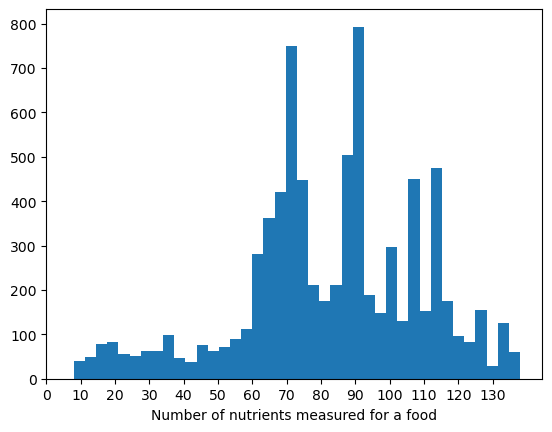

In [7]:

nutrient = nutrient_r.loc[:, 'id':'unit_name']
nutrient = nutrient.rename(columns={'name': 'nutrient'})
nutrient.loc[nutrient['id']==1062, 'nutrient'] = 'Energy (kJ)'
print_df(nutrient, 'nutrient', rows=10)
  
category = category_r.drop('code', axis=1).rename(columns={'description': 'category'})
print_df(category, 'category')

# print('All food categories:', category['description'].values, sep='\n')

if vegan:
    cat = [
        'Fats and Oils', 'Fruits and Fruit Juices',
        'Vegetables and Vegetable Products', 'Nut and Seed Products',
        'Legumes and Legume Products', 'Cereal Grains and Pasta',
    ]

    print('Chosen vegan food categories:', cat, sep='\n', end='\n'*2)

else:
    cat = [
        'Dairy and Egg Products', 'Fats and Oils', 'Fruits and Fruit Juices',
        'Vegetables and Vegetable Products', 'Nut and Seed Products',
        'Legumes and Legume Products', 'Cereal Grains and Pasta', 
        'Pork Products', 'Beef Products', 'Finfish and Shellfish Products',
        'Lamb, Veal, and Game Products'
    ]
    print('Chosen food categories:', cat, sep='\n', end='\n'*2)

food = food_r.drop(['data_type', 'publication_date'], axis=1)
food.rename(columns={'description': 'food'}, inplace=True)
print_df(food, 'food')

# The nutrient amount is for a 100 g portion
food_nutrient = food_nutrient_r.loc[:, 'fdc_id':'amount']
food_nutrient = food_nutrient.rename(columns={'amount': 'nutrient_amount'})
print_df(food_nutrient, 'food_nutrient')


portion = portion_r[['seq_num', 'fdc_id', 'amount',
                    'modifier', 'gram_weight']]
portion = portion.rename(columns={'amount': 'portion',
                                  'gram_weight': 'portion_grams'})

# Take only the first type of portion if there are more than one
portion = portion[portion['seq_num'] == 1]
portion.drop('seq_num', axis=1, inplace=True)
print_df(portion, 'portions')

# How may nutrients where measured for each food
ids, counts = np.unique(food_nutrient['fdc_id'].values, return_counts=True)

plt.hist(counts, bins='auto')
plt.xlabel('Number of nutrients measured for a food')
plt.xticks(np.arange(0,max(counts), 10))
plt.show()


In [8]:
# merge foods with categories on the category id
df = pd.merge(food, category, left_on='food_category_id', 
              right_on='id')
df.drop(['id', 'food_category_id'], inplace=True, axis=1)
print_df(df, 'food merged with category')

# Select foods based on whether they are in vegan categories or not
target_food = df[df['category'].isin(cat)]

print_df(target_food, 'food filtered based on chosen categories')

food_basic_desc = target_food.copy()

# Include foods with missing portion sizes as the nutrient measurements
# assume a 100 g portion so we do not need portion amounts provided.
target_food = target_food.merge(portion, on='fdc_id', how='left')
print_df(target_food, 'food with portion size')

# Store the total number of foods
N_FOODS = target_food.shape[0]

# Merge food and nutrient measurements
target_food = target_food.merge(food_nutrient, on='fdc_id', validate='1:m')
print_df(target_food, 'food portion with nutrient ids')

# Merge food and nutrients measurements with nutrient names
target_food = target_food.merge(nutrient, left_on='nutrient_id',
                              right_on='id', validate='m:1')

target_food = target_food.drop(['id', 'nutrient_id'], axis=1)
print_df(target_food, 'food portion with nutrient amounts')


DataFrame of food merged with category with shape (7793, 3):
   fdc_id                                               food        category
0  167512  Pillsbury Golden Layer Buttermilk Biscuits, Ar...  Baked Products
1  167513  Pillsbury, Cinnamon Rolls with Icing, refriger...  Baked Products
2  167514  Kraft Foods, Shake N Bake Original Recipe, Coa...  Baked Products
3  167515     George Weston Bakeries, Thomas English Muffins  Baked Products
4  167516         Waffles, buttermilk, frozen, ready-to-heat  Baked Products

DataFrame of food filtered based on chosen categories with shape (1993, 3):
    fdc_id                                               food  \
90  167602    Seaweed, Canadian Cultivated EMI-TSUNOMATA, dry   
91  167603  Seaweed, Canadian Cultivated EMI-TSUNOMATA, re...   
92  167604     Potatoes, hash brown, refrigerated, unprepared   
93  167605  Potatoes, hash brown, refrigerated, prepared, ...   
94  167606  Sweet Potatoes, french fried, frozen as packag...   

         

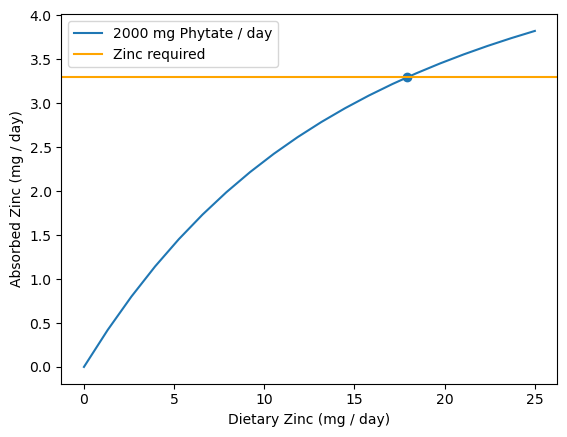

Dietary zinc needed: 17.90 mg per day for 2000 mg phytate per day

Calcium, Ca uses units of ['MG']
Carotene, beta uses units of ['UG']
Cholesterol uses units of ['MG']
Choline, total uses units of ['MG']
Energy uses units of ['KCAL']
Fiber, total dietary uses units of ['G']
Folate, total uses units of ['UG']
Histidine uses units of ['G']
Iron, Fe uses units of ['MG']
Isoleucine uses units of ['G']
Leucine uses units of ['G']
Lysine uses units of ['G']
Magnesium, Mg uses units of ['MG']
Methionine uses units of ['G']
Niacin uses units of ['MG']
PUFA 18:2 uses units of ['G']
PUFA 18:3 uses units of ['G']
Pantothenic acid uses units of ['MG']
Phenylalanine uses units of ['G']
Phosphorus, P uses units of ['MG']
Potassium, K uses units of ['MG']
Protein uses units of ['G']
Riboflavin uses units of ['MG']
Selenium, Se uses units of ['UG']
Sodium, Na uses units of ['MG']
Thiamin uses units of ['MG']
Threonine uses units of ['G']
Total lipid (fat) uses units of ['G']
Tryptophan uses units of 

In [9]:
# Number of measurement for each nutrient
# target_food.groupby('nutrient').apply(lambda df: print(df.shape[0], df['nutrient'].iloc[0]))
# Energy has two measurements per food: kJ and kCal

all_nutrients = sorted(set(target_food['nutrient'].values))
# print(all_nutrients)

# 35% of energy can come from healthy fats (saturated or not)
# 9 kcal / g fat
t_fat = kcal * 0.35 / 9
#FAO recommends 8 mg Histidine / kg body weight
hist = weight * 12 / 1000
# Iron: 0.8 - 1.0 mg iron/day is lost. 9 mg / day is recommended 
# To account for non-heme iron, increase to 18 mg / day
if vegan:
    fe = 18
else:
    fe = 9
# Protein: EFSA set 0.83 g protein / kg body weight: 70 * 0.8 = 56 g
protein = 0.83 * weight
# 20% of energy from protein would be 560 kcal / 4 kcal-g = 140 g
# EFSA recommends 1 μg phylloquinone/kg body
vit_e = weight
# EFSA recommends 950 mg Ca per day https://www.efsa.europa.eu/en/efsajournal/pub/4101
# EFSA recommends 6.6 mg Niacin equiv / 1000 kcal
niacin = 6.6 * kcal / 1000
# EFSA recommends 0.4 mg Thiamin equiv / 1000 kcal
thiamin = 0.4 * kcal / 1000
# EFSA recommends between 2-4 g omega-3 PUFU 18:3
# A target of omega-6/omega-3 fatty acid ratio of 1:1 to 2:1 appears 
# to be consistent with studies on evolutionary aspects of diet.
# https://www.ocl-journal.org/articles/ocl/full_html/2010/05/ocl2010175p267/ocl2010175p267.html
# EFSA recommends 5 mg / day for pantothenic acid (Vit B5), 550 mg P / day
# 3500 mg K / day, 750 µg Vitamin A / day (12x this for beta-carotene), 
# 1.6 mg Riboflavin / day,
# 70 µg Selenium / day, maximum 2400 mg Na / day, 1.7 mg B6 /day,
# 110 mg ascorbic acid /day

# Model used to determine absorbed zinc from dietary zinc and phytates: 
#https://doi.org/10.2903/j.efsa.2014.3844 (all in mmol / day)

# Physiological zinc requirement [mg/day] 
r_zinc = 0.642 + 0.038 * weight

# Model is from mg dietary zinc / day to mg absorbed zinc / day
def taz(tdz, tdp): 
    tdz /= 65.38
    tdp /= 660.029
    y = 0.033 * (1+tdp/0.68) + 0.091 + tdz
    return 0.5 * (y - np.sqrt(y**2 - 4*0.091*tdz)) * 65.38
# the first derivative of the function taz
def d_taz(tdz, tdp):
    tdz  /= 65.38
    tdp /= 660.029
    y = 0.033 * (1+tdp/0.68) + 0.091 + tdz
    return 0.5 - (2*y - 4*0.091) / (4 * np.sqrt(y**2 - 4*0.091*tdz))

# Inverse of a function f at y using newtons method given df/dx
def solve_inv(x_0, f, df, y, *args):
    x = x_0
    while (abs(f(x, *args) - y) > 0.01):
        x = x - (f(x, *args) - y) / df(x, *args)

    return x

if vegan:
# TODO: estimate phytate consumption to be 2000 mg / day for vegan diet
# https://www.feedtables.com/content/phytate-phosphorus
    tdp = 2000
else:
    # for a non-vegan diet
    tdp = 1300


zinc = solve_inv(1, taz, d_taz, r_zinc, tdp)
z_max = 25
tdz = np.linspace(0, z_max, 20)
plt.plot(tdz, taz(tdz.copy(), tdp), label=f'{tdp} mg Phytate / day')
plt.axhline(r_zinc, c='orange', label='Zinc required')
plt.scatter(zinc, r_zinc, zorder=0)
plt.xlabel('Dietary Zinc (mg / day)')
plt.ylabel('Absorbed Zinc (mg / day)')
plt.legend()
plt.show()

print(f'Dietary zinc needed: {zinc:.2f} mg per day' \
      f' for {tdp} mg phytate per day', end='\n'*2)

# WHO recommendations for essential AAs in mg / kg body weight
# https://iris.who.int/handle/10665/43411
target_aa = {
    'Leu': 39,
    'Lys': 30,
    'Ile': 20,
    'Val': 26,
    'Thr': 15,
    'Phe': 25,
    'Trp': 4,
    'Met': 15,
    'His': 10
}
conv_fac = weight / 1000
# Calculate the total amounts of needed amino acids in grams
aa_t = {a: mg * conv_fac for a, mg in target_aa.items()}

'''
     values indicate daily reference value;
    None indicates no recommended amount 
    from literature. 
'''

# target_nutrients = {
#     'Calcium, Ca': 950, 'Carbohydrate, by difference': None, 
#     'Carotene, beta': 750 * 12, 'Cholesterol': 300, 'Choline, total': 400, 
#     'Energy': kcal, 'Fatty acids, total monounsaturated': None, 
#     'Fatty acids, total polyunsaturated': None, 
#     'Fatty acids, total saturated': None,
#     'Fiber, total dietary': 25, 'Folate, total': 350, 
#     'Histidine': aa_t['His'], 'Iron, Fe': fe, 'Isoleucine': aa_t['Ile'], 
#     'Leucine': aa_t['Leu'], 'Lysine': aa_t['Lys'], 'Magnesium, Mg': 350, 
#     'Methionine': aa_t['Met'], 'Niacin': niacin, 'PUFA 18:2': 8, 
#     'PUFA 18:3': 4, 'Pantothenic acid': 5, 'Phenylalanine': aa_t['Phe'], 
#     'Phosphorus, P': 550, 'Potassium, K': 3500, 'Protein': protein, 
#     'Riboflavin': 1.6, 'Selenium, Se': 70, 'Sodium, Na': 2400, 
#     'Thiamin': thiamin, 'Threonine': aa_t['Thr'], 'Total lipid (fat)': t_fat, 
#     'Tryptophan': aa_t['Trp'], 'Valine': aa_t['Val'], 'Vitamin A, RAE': 750, 
#     'Vitamin B-6': 1.7, 'Vitamin C, total ascorbic acid': 110, 
#     'Vitamin K (phylloquinone)': vit_e, 'Zinc, Zn': zinc
# }

target_nutrients = {
    'Calcium, Ca': 950,
    'Carotene, beta': 750 * 12, 'Cholesterol': 300, 'Choline, total': 400, 
    'Energy': kcal, 'Fiber, total dietary': 25, 'Folate, total': 350, 
    'Histidine': aa_t['His'], 'Iron, Fe': fe, 'Isoleucine': aa_t['Ile'], 
    'Leucine': aa_t['Leu'], 'Lysine': aa_t['Lys'], 'Magnesium, Mg': 350, 
    'Methionine': aa_t['Met'], 'Niacin': niacin, 'PUFA 18:2': 8, 
    'PUFA 18:3': 4, 'Pantothenic acid': 5, 'Phenylalanine': aa_t['Phe'], 
    'Phosphorus, P': 550, 'Potassium, K': 3500, 'Protein': protein, 
    'Riboflavin': 1.6, 'Selenium, Se': 70, 'Sodium, Na': 2400, 
    'Thiamin': thiamin, 'Threonine': aa_t['Thr'], 'Total lipid (fat)': t_fat, 
    'Tryptophan': aa_t['Trp'], 'Valine': aa_t['Val'], 'Vitamin A, RAE': 750, 
    'Vitamin B-6': 1.7, 'Vitamin C, total ascorbic acid': 110, 
    'Vitamin K (phylloquinone)': vit_e, 'Zinc, Zn': zinc
}

# Print units for each target nutrient
for name in target_nutrients.keys():
    unit = nutrient.loc[nutrient['nutrient'] == name, 'unit_name'].values
    print(f'{name} uses units of {unit}')


target_food = target_food.loc[
    target_food['nutrient'].isin(target_nutrients.keys()), :]
print_df(target_food, 'foods with selected nutrients')

In [10]:
# Add new columns for the daily targets for nutrients (DV) and the percent
# that each food satisfies the requirement.
target_food['DV'] = target_food['nutrient'].apply(lambda x: target_nutrients[x])

target_food["%DV"] = (100 * target_food["nutrient_amount"] / target_food["DV"]).where(target_food["DV"].notna())

print_df(target_food, 'adds DV and %DV')

DataFrame of adds DV and %DV with shape (59628, 11):
   fdc_id                                             food  \
0  167602  Seaweed, Canadian Cultivated EMI-TSUNOMATA, dry   
2  167602  Seaweed, Canadian Cultivated EMI-TSUNOMATA, dry   
6  167602  Seaweed, Canadian Cultivated EMI-TSUNOMATA, dry   
7  167602  Seaweed, Canadian Cultivated EMI-TSUNOMATA, dry   
8  167602  Seaweed, Canadian Cultivated EMI-TSUNOMATA, dry   

                            category  portion modifier  portion_grams  \
0  Vegetables and Vegetable Products     0.25      cup            5.0   
2  Vegetables and Vegetable Products     0.25      cup            5.0   
6  Vegetables and Vegetable Products     0.25      cup            5.0   
7  Vegetables and Vegetable Products     0.25      cup            5.0   
8  Vegetables and Vegetable Products     0.25      cup            5.0   

   nutrient_amount           nutrient unit_name           DV        %DV  
0             1.39  Total lipid (fat)         G   108.888889 

In [11]:
# Filter the foods according to their categories / names.

food_names = target_food['food']
food_categories = target_food['category']

def contains_pattern(df, pat, regex=False):
    # returns a boolean array
    return df.str.lower().str.contains(pat, regex=regex)

def select_categories(series, categories):
    return series.isin(categories)

print(contains_pattern(pd.Series(["Seeds, cottonseed kernels, roasted (glandless)"]),
                 "cottonseed"))

print(select_categories(pd.Series(["Nut and Seed Products"]), 
                        ['Nut and Seed Products']))

if vegan: 
    stop_words = [
        'isolate', 'dehydrated', 'dried', 'concentrate', 'enrich', 'dry',
        'fried', 'added', 'uncooked', 'meat', 'fish', 'beef', 'pork', 
        'chicken', 'fortified', 'crude', 'lard', 'bran', 'butter', 'fat',
        'salad dressing', 'mayo', 'vegetarian', 'egg', 'fresh-refrigerated',
        'juice', 'spread', 'margarine', 'noodles', 'powder', 'canned',
    ]
    cottonseed = contains_pattern(food_names, 'cottonseed')

    pattern = re.compile('|'.join(stop_words), flags=re.IGNORECASE)
    stopped = ~contains_pattern(food_names, pattern, regex=True) 
    nuts_seeds = select_categories(food_categories, ['Nut and Seed Products'])
    
    # stopword all foods but nuts\seeds, and remove cottonseed from nuts/seeds
    target_food = target_food.loc[(~nuts_seeds & stopped) | \
                                  (nuts_seeds & ~cottonseed), :]
    
    food_names = target_food['food']
    food_categories = target_food['category']

    grains_legumes = select_categories(food_categories, 
                                       ['Legumes and Legume Products',
                                        'Cereal Grains and Pasta'])
    raw = contains_pattern(food_names, 'raw')

    # Do not include raw legumes or grains
    target_food = target_food.loc[~grains_legumes | (grains_legumes & ~raw), :]


# Includes non-vegan options
else:
    stop_words = [
        'isolate', 'dehydrated', 'dried', 'concentrate', 'enrich', 'dry',
        'fried', 'added', 'uncooked', 'fortified', 'crude', 'bran', 
        'fat', 'powder', 'canned', 'juice', 'spread',
    ]
    cottonseed = contains_pattern(food_names, 'cottonseed')

    pattern = re.compile('|'.join(stop_words), flags=re.IGNORECASE)
    stopped = ~contains_pattern(food_names, pattern, regex=True) 
    nuts_seeds = select_categories(food_categories, ['Nut and Seed Products'])
    
    # stopword all foods but nuts\seeds, and remove cottonseed from nuts/seeds
    target_food = target_food.loc[(~nuts_seeds & stopped) | \
                                  (nuts_seeds & ~cottonseed), :]
    
    food_names = target_food['food']
    food_categories = target_food['category']

    # Do not include foods that are not eaten raw
    raw = contains_pattern(food_names, 'raw')
    raw_foods = (target_food['category'] == 'Vegetables and Vegetable Products') | \
                    (target_food['category'] ==   'Nut and Seed Products') | \
                     (target_food['category'] ==   'Fruits and Fruit Juices')
    
    target_food = target_food[ raw_foods | (~raw_foods & ~raw)]

print(target_food.shape)

# shape is 34927, 11

0    True
dtype: bool
0    True
dtype: bool
(34927, 11)


In [12]:
# pivot nutrients %DV so that they become columns
nut_columns = target_food.pivot(index='fdc_id', 
                                columns='nutrient', values='%DV')
# merge with the food names and categories
food = food_basic_desc.merge(nut_columns, on='fdc_id')

print(food.head())

   fdc_id                                               food  \
0  167603  Seaweed, Canadian Cultivated EMI-TSUNOMATA, re...   
1  167604     Potatoes, hash brown, refrigerated, unprepared   
2  167702                        Oil, flaxseed, cold pressed   
3  167714                                Hearts of palm, raw   
4  167722                                        Tofu yogurt   

                            category  Calcium, Ca  Carotene, beta  \
0  Vegetables and Vegetable Products     3.789474        6.577778   
1  Vegetables and Vegetable Products     0.631579             NaN   
2                      Fats and Oils     0.105263        0.000000   
3  Vegetables and Vegetable Products     1.894737        0.455556   
4        Legumes and Legume Products    12.421053        0.222222   

   Cholesterol  Choline, total     Energy  Fiber, total dietary  \
0          NaN             NaN   1.107143                  18.0   
1          0.0           3.625   3.000000                   7.2   

In [13]:
# plot kde's of DV for each nutrient in each category
import seaborn as sns
import math

plot_nutrients = False

if plot_nutrients:
    n = len(target_nutrients)
    n_cols = 2
    n_rows = math.ceil(n / n_cols)

    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols)
    # multi-index iterator for plots
    it = np.nditer(np.zeros((n_rows, n_cols)), flags=['multi_index'])

    for nutr in target_nutrients:
        next(it)
        sns.kdeplot(data=food[["category", nutr]], 
                    x=nutr, hue="category", 
                    hue_order=cat,
                    clip=[2,100], ax=axes[it.multi_index],
                    warn_singular=False, common_norm=False, common_grid=False,)
        
        axes[it.multi_index].set_title(nutr)
        

    fig.set_size_inches(h=n_rows * 4, w=n_cols * 5)
    fig.suptitle("Vegan foods" if vegan else "All foods", y=1)
    plt.tight_layout()
    plt.show()


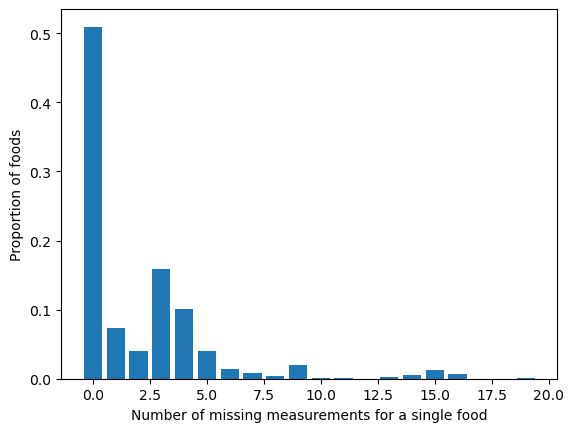

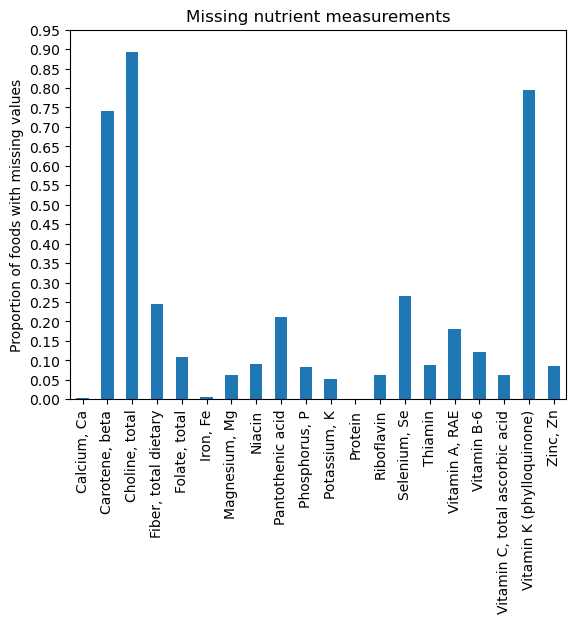

In [14]:
target_nutrients = {
    'Calcium, Ca': 950,
    'Carotene, beta': 750 * 12, 'Choline, total': 400, 
    'Fiber, total dietary': 25, 'Folate, total': 350, 
    'Iron, Fe': fe, 'Magnesium, Mg': 350, 
    'Niacin': niacin, 'Pantothenic acid': 5,
    'Phosphorus, P': 550, 'Potassium, K': 3500, 'Protein': protein, 
    'Riboflavin': 1.6, 'Selenium, Se': 70, 
    'Thiamin': thiamin, 'Vitamin A, RAE': 750, 
    'Vitamin B-6': 1.7, 'Vitamin C, total ascorbic acid': 110, 
    'Vitamin K (phylloquinone)': vit_e, 'Zinc, Zn': zinc
}

df = food[list(target_nutrients.keys())].isna().sum(axis=1) 
vals, counts = np.unique_counts(df.values)
n_has_missing = sum(counts[1:])
plt.bar(vals, counts / sum(counts))
plt.ylabel("Proportion of foods")
plt.xlabel("Number of missing measurements for a single food")
plt.show()

# Plot the frequency of missing values for each nutrient
df = food[list(target_nutrients.keys())].isna().sum(axis=0) / n_has_missing
ax = df.plot(kind='bar')
ax.set_title("Missing nutrient measurements")
ax.set_ylabel("Proportion of foods with missing values")
ax.set_yticks(np.arange(0, 1, 0.05))

# important for simulating missing values
p_missing = df.values

plt.show()


In [15]:
from scipy.stats import kendalltau
import scipy.special as special

def k_kendall_dist(a, b, k):

    # we want the indices of the top k rankings, the order does not matter
    a_top_k = np.argpartition(a,-k)[-k:]
    b_top_k = np.argpartition(b,-k)[-k:]

    shared = np.intersect1d(a_top_k,b_top_k)
    # for case 2
    only_in_a = np.setdiff1d(a_top_k, shared)
    only_in_b = np.setdiff1d(b_top_k, shared)

    n = shared.size

    k_dist = 0
    # assume that a and b are top-k lists.
    # case 1
    if n > 1: # distance undefined for 1 item permutations
        k_dist = (1 - kendalltau(a[shared], b[shared])[0]) * n * (n-1) / 4
    # case 2
    for i in shared:
        for j in only_in_a:
            if a[i] < a[j]:
                k_dist += 1
        for j in only_in_b:
            if b[i] < b[j]:
                k_dist += 1

    # case 3: if {i,j} in a/b and only i or j is the other
    k_dist += (k-n)**2

    # case 4: if {i,j} in a but not b vice versa
    # if we have access to the other items in the lists (not just top k):
    # check a[i] < a[j] and b[i] < b[j] or a[i] > a[j] and b[i] > b[j]
    # holds true for each {i, j}. 
    # If there are y items only in a/b then there are y choose 2 pairs for 
    # each list. The total is then k-n choose 2 pairs that are out of order 
    # that need to be checked or apply penalty (p) for each pair.
    # apply penalty p:
    k_dist += 2 * special.binom(k-n,2)

    print(k * (k-1) / 2)

    return k_dist



In [45]:
from scipy.stats import spearmanr, kendalltau

def nutrient_score_2d(values):
    mask = ~np.isnan(values)
    '''
        Harmonic mean
        But how do we consider missing values? If we ignore them, is
        there is bias towards foods with many missing values and a few
        moderate measurements (not effected by smaller values.) 

        Also, measurements of 0 prevent the calculation so they must
        be accounted for somehow. Add a small delta for 0 values.
        
        Besides these, the harmonic means makes sense since we want the average
        of ratios with different denominators (amount / DV's).
    '''
    return np.sum(mask, axis=1) / np.sum(np.reciprocal(values+0.01), where=mask,
                                         axis=1)


# How does harmonic mean fluctuate across possible 
# missingness patterns or imputed datasets.

# TODO: compare different score functions with ignoring, vs imputing 
# missing values

# https://en.wikipedia.org/wiki/Tobit_model
# https://pmc.ncbi.nlm.nih.gov/articles/PMC5809088/

# select all foods that have all measurements f_comp
cols = list(target_nutrients.keys())
f_comp = food.dropna()[cols].values




def eval_score_metrics(f_comp, score=lambda x: np.ones(x.shape),
                       b=2000, k=20, imp_func= lambda x: x):

    n = f_comp.shape[0]
    # compute the harmonic mean for each (s_comp)
    s_comp = score(f_comp)

    # draw b bootstrap samples

    # Look at top k retention


    edges = [0, 0.2, 0.25, 0.3, 1]
    n_edges = len(edges)

    # we are computing 2 metrics: spearman rank, top 10% retention
    # for the bins define by edges
    bs_vals = np.zeros((b, n_edges-1, 2))

    def compute_rank_metrics(rank_orig, rank_new, k):

        # proportion discordant pairs (opposite orders in lists)
        dist = (1-kendalltau(rank_orig, rank_new)[0])/2

        # top-k retention
        retention = np.mean(np.isin(rank_orig.argsort()[-k:], 
                            rank_new.argsort()[-k:],
                            assume_unique=True))

        return dist, retention

    for b_i in range(b):

        # For each food in f_comp, artificially apply missing values according
        # to frequencies in data to generate a new dataset f_miss
        f_miss = f_comp.copy()
        probs = p_missing.reshape(1, -1) * np.ones((n, 1))
        assert probs.shape == (n, len(cols))

        mask = np.random.random(f_miss.shape) < probs
        f_miss[mask] = np.nan

        # compute the proportion of missing values for each entry
        prop_missing = np.sum(mask, axis=1) / f_miss.shape[1]

        # apply some imputation of missing values (default to none)
        f_miss = imp_func(f_miss)

        # compute the harmonic mean for each (s_miss)
        s_miss = score(f_miss)

        # Rank the scores
        rank_comp = s_comp.argsort().argsort()
        rank_miss = s_miss.argsort().argsort()

        # Group results based on proportion of missing values for entries

        # This is splitting into equally ranged bins
        # TODO: this has to be constant across samples so bins remain the same

        # for each entry assign it a bin
        bin_idx = np.digitize(prop_missing, edges)

        for idx in range(1, n_edges):
            bin = bin_idx == idx
            rank_miss_bin = rank_miss[bin]
            rank_comp_bin = rank_comp[bin]

            bs_vals[b_i, idx-1] = compute_rank_metrics(rank_comp_bin, 
                                                    rank_miss_bin,
                                                    k=k)
            
    # compute the bootstrap percentile intervals for each metric and bin
    alpha = 0.05
    lower = np.percentile(bs_vals, 100 * alpha / 2, axis=0)
    upper = np.percentile(bs_vals, 100 * (1 - alpha / 2), axis=0)

    print(f"For {b} Bootstrap samples:\n")
    for i, lb, ub in (zip(range(n_edges), lower, upper)):
        print(f"For foods with proportion missing in: [{edges[i]}, {edges[i+1]})")
        print(f"\t Proportion discordant pairs 95% CI: [{lb[0]:.4f}, {ub[0]:.4f}]")
        print(f"\t Top-{k} Retention 95% CI: [{lb[1]}, {ub[1]}]\n")




# For foods with missing values, impute them to create a new dataset f_imp

def impute_mean(arr):
    column_means = np.nanmean(arr, axis=0)
    arr_filled = np.where(np.isnan(arr), column_means, arr)
    return arr_filled

def impute_median(arr):
    column_means = np.nanmedian(arr, axis=0)
    arr_filled = np.where(np.isnan(arr), column_means, arr)
    return arr_filled

from sklearn.impute import KNNImputer

def impute_knn(arr):
# Initialize imputer with regression estimator
    imputer = KNNImputer(n_neighbors=2, weights="uniform")
    # Fit and transform
    return imputer.fit_transform(arr)

print("Ignoring missing values, harmonic mean score:")
eval_score_metrics(f_comp=f_comp, score=nutrient_score_2d)
print("Replace missing values with mean, harmonic mean score:")
eval_score_metrics(f_comp=f_comp, score=nutrient_score_2d, 
                   imp_func=impute_mean)
print("Replace missing values with median, harmonic mean score:")
eval_score_metrics(f_comp=f_comp, score=nutrient_score_2d, 
                   imp_func=impute_median)

print("Ignoring missing values, sum as score:")
eval_score_metrics(f_comp, score=lambda x: np.nansum(x, axis=1))

# eval_score_metrics(f_comp=f_comp, score=nutrient_score_2d, 
#                    imp_func=impute_knn)

print("Ignoring missing values, mean as score:")
eval_score_metrics(f_comp, score=lambda x: np.nanmean(x, axis=1))




Ignoring missing values, harmonic mean score:
For 2000 Bootstrap samples:

For foods with proportion missing in: [0, 0.2)
	 Proportion discordant pairs 95% CI: [0.0575, 0.0922]
	 Top-20 Retention 95% CI: [0.7, 0.95]

For foods with proportion missing in: [0.2, 0.25)
	 Proportion discordant pairs 95% CI: [0.0790, 0.1311]
	 Top-20 Retention 95% CI: [0.6, 0.9]

For foods with proportion missing in: [0.25, 0.3)
	 Proportion discordant pairs 95% CI: [0.0918, 0.1625]
	 Top-20 Retention 95% CI: [0.55, 0.85]

For foods with proportion missing in: [0.3, 1)
	 Proportion discordant pairs 95% CI: [0.1032, 0.2116]
	 Top-20 Retention 95% CI: [0.5, 0.85]

Replace missing values with mean, harmonic mean score:
For 2000 Bootstrap samples:

For foods with proportion missing in: [0, 0.2)
	 Proportion discordant pairs 95% CI: [0.0588, 0.0941]
	 Top-20 Retention 95% CI: [0.65, 0.95]

For foods with proportion missing in: [0.2, 0.25)
	 Proportion discordant pairs 95% CI: [0.0785, 0.1296]
	 Top-20 Retention 

Overall:
Spearman Corr: 0.9068185446969254
p-value < 0.05: True
Top 10% Retention: 0.7659574468085106


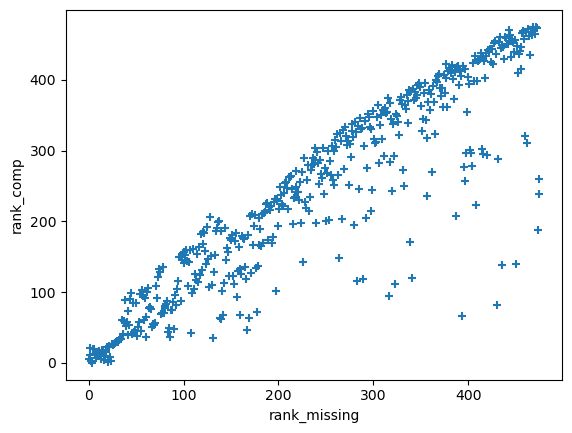

0.05 <= prop_missing < 0.15
Spearman Corr: 0.9456613509513067 and p-value < 0.05: True
Top 10% Retention: 0.7333333333333333
Average difference in ranking: 33.18354430379747


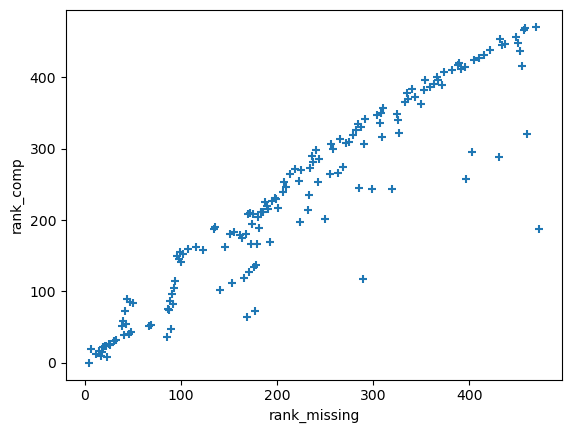

0.15 <= prop_missing < 0.2
Spearman Corr: 0.9338113789117685 and p-value < 0.05: True
Top 10% Retention: 0.9285714285714286
Average difference in ranking: 35.87943262411348


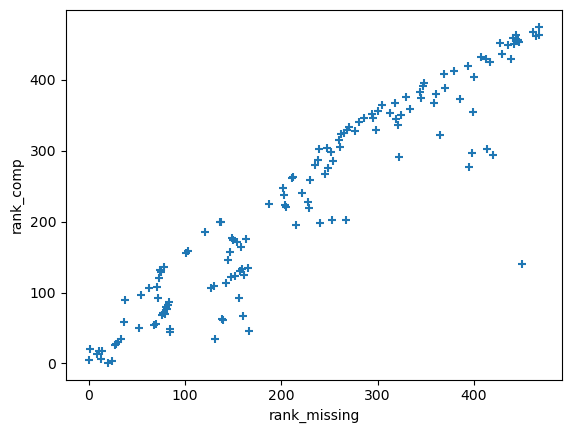

0.2 <= prop_missing < 0.25
Spearman Corr: 0.8692066072134604 and p-value < 0.05: True
Top 10% Retention: 0.6
Average difference in ranking: 40.49514563106796


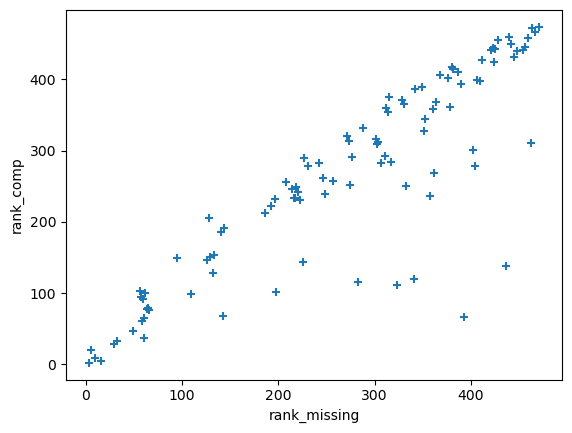

In [ ]:
from scipy.stats import spearmanr

def nutrient_score_2d(values):
    mask = ~np.isnan(values)
    '''
        Harmonic mean
        But how do we consider missing values? If we ignore them, is
        there is bias towards foods with many missing values and a few
        moderate measurements (not effected by smaller values.) 

        Also, measurements of 0 prevent the calculation so they must
        be accounted for somehow. Add a small delta for 0 values.
        
        Besides these, the harmonic means makes sense since we want the average
        of ratios with different denominators (amount / DV's).
    '''
    return np.sum(mask, axis=1) / np.sum(np.reciprocal(values+0.01), where=mask,
                                         axis=1)


# How does harmonic mean fluctuate across possible 
# missingness patterns or imputed datasets.

# select all foods that have all measurements f_comp

cols = list(target_nutrients.keys())

f_comp = food.dropna()[cols].values

n = f_comp.shape[0]

# compute the harmonic mean for each (s_comp)

s_comp = nutrient_score_2d(f_comp)


# TODO: draw more samples (n * b) rows

# For each food in f_comp, artificially apply missing values according
# to frequencies in data to generate a new dataset f_miss
f_miss = f_comp.copy()

probs = p_missing.reshape(1, -1) * np.ones((n, 1))
mask = np.random.random(f_comp.shape) < probs
f_miss[mask] = np.nan

# compute the proportion of missing values for each entry
prop_missing = np.sum(mask, axis=1) / f_miss.shape[1]

# compute the harmonic mean for each (s_miss)
s_miss = nutrient_score_2d(f_miss)

# Rank s_miss and s_comp 
rank_comp = s_comp.argsort().argsort()
rank_miss = s_miss.argsort().argsort()

print("Overall:")
res = spearmanr(rank_miss, rank_comp)
print("Spearman Corr:", res.statistic)
print("p-value < 0.05:", res.pvalue < 0.05)

# get the top ten ranks and determine their retention in missing data
# set.
top = int(n * 0.1)
retention =np.mean(np.isin(rank_comp.argsort()[-top:], 
                           rank_miss.argsort()[-top:]))
print("Top 10% Retention:", retention)


plt.scatter(rank_miss, rank_comp,  marker='+')
plt.xlabel("rank_missing")
plt.ylabel("rank_comp")
plt.show()
'''
Plot shows high correlation between rankings. In cases where there is a
significant difference, entries with missing values tend to rank higher 
rather than lower compared to the original. This suggests that
the relative score tends to be upward biased for foods with missing values.
'''

# Group results based on proportion of missing values for entries

# This is splitting into equally ranged bins
# TODO: this has to be constant across samples so bins remain the same
max_prop = max(prop_missing)
bin_width = 0.20
edges = np.arange(0, max_prop+bin_width, bin_width)
n_edges = len(edges)

# for each entry assign it a bin
bin_idx = np.digitize(prop_missing, edges)

# use equally sized bins via quartiles. will not be as useful for multiple trials
# since the bins will likely change across bootstrap samplings.
n_edges = 4 # n_edges - 1 = n_bins
bin_idx, edges = pd.qcut(prop_missing, q=n_edges, retbins=True,
                  labels=False, duplicates='drop')
bin_idx += 1

for idx in range(1, n_edges):
    bin = bin_idx == idx
    rank_miss_bin = rank_miss[bin]
    rank_comp_bin = rank_comp[bin]

    # Spearman rank correlation
    print(f"{edges[idx-1]} <= prop_missing < {edges[idx]}")
    res = spearmanr(rank_miss_bin, rank_comp_bin)
    print("Spearman Corr:", res.statistic, 
          "and p-value < 0.05:", res.pvalue < 0.05)

    # Top 10% retention
    top = int(len(rank_miss_bin) * 0.1)
    retention = np.mean(np.isin(rank_comp_bin.argsort()[-top:], 
                                rank_miss_bin.argsort()[-top:]))
    print("Top 10% Retention:", retention)

    # Avg Rank jumps |rank(s_full) - rank(s_miss)|
    jump = np.mean(np.abs(rank_comp_bin - rank_miss_bin))
    print("Average difference in ranking:", jump)


    plt.scatter(rank_miss_bin, rank_comp_bin,  marker='+')
    plt.xlabel("rank_missing")
    plt.ylabel("rank_comp")
    plt.show()


# For foods with missing values, impute them to create a new dataset f_imp



In [197]:
import json

# write out the target nutrients with their DVs to a JSON 
with open('target_nutrients.json', 'w') as f:
    f.write(json.dumps(target_nutrients, indent=4))

# write out the prepared dataframe
if vegan:
    food.to_csv("vegan_food.csv")
else:
    food.to_csv("food.csv")


In [198]:
def nutrient_score(values):
    values = values[~np.isnan(values)]
    '''
        Harmonic mean
        But how do we consider missing values? If we ignore them, then
        there is bias towards foods with many missing values and a few
        moderate measurements (not effected by smaller values.) 

        Also, measurements of 0 prevent the calculation so they must
        be accounted for somehow.
        
        Besides these, the harmonic means makes sense since we want the average
        of ratios with different denominators (amount / DV's).
    '''
    return len(values) / np.sum(np.reciprocal(values+0.01))

target_nutrients = {
    'Calcium, Ca': 950,
    'Carotene, beta': 750 * 12, 'Choline, total': 400, 
    'Fiber, total dietary': 25, 'Folate, total': 350, 
    'Iron, Fe': fe, 'Magnesium, Mg': 350, 
    'Niacin': niacin, 'Pantothenic acid': 5,
    'Phosphorus, P': 550, 'Potassium, K': 3500, 'Protein': protein, 
    'Riboflavin': 1.6, 'Selenium, Se': 70, 'Sodium, Na': 2400, 
    'Thiamin': thiamin, 'Vitamin A, RAE': 750, 
    'Vitamin B-6': 1.7, 'Vitamin C, total ascorbic acid': 110, 
    'Vitamin K (phylloquinone)': vit_e, 'Zinc, Zn': zinc
}

# Add a column for nutrient score
food["score"] = food[list(target_nutrients.keys())].apply(nutrient_score, axis=1)
# divide by the energy density kcal/g
# food["score"] = food["score"] / food["Energy"] / 100 * kcal / 100

# get the top n foods for each nutrient in each category to csv
idx = food.groupby(['category'])['score'].nlargest(30).index.get_level_values(1)
cols = ['category', 'food', 'score']
cols.extend(list(target_nutrients.keys()))
temp = food.loc[idx, cols]
temp.to_csv('top_score.csv', index=False, float_format='%.3f')